<a href="https://colab.research.google.com/github/garnerdusting-gif/OAP_2021_Revisited/blob/main/OAP_2021_Revisited.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The raw data exported from the survey software included metadata rows and 22 incomplete responses. I utilized Pandas to clean the dataset, standardizing column names and isolating responses required for accurate statistical analysis. The target of $N=25$ complete responses is being investigated as the initial cleaning steps were too aggressive.

Import all necessary libraries.

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

The data I used for this project came from a Qualtrics survey. Qualtrics has two rows of metadata that need to be handled first. I used Python to create a "cheat sheet" of current column names and their associated survey questions, then used it to create new column names. The naming convention varied by question type: demographic questions were named based on the demographic being measured, and I used inv_ or sat_ with the associated activity to create involvement and satisfaction names. inv = involvement, sat = satisfaction,
 fre = frequency, dur = duration

In [106]:

#Load the raw data from a .csv file.
df_raw = pd.read_csv('oap_data.csv')
# Data comes from a qualtrics survey, so the first two rows are survey metadata.

#df_clean = df.iloc[2:].copy()
print("--- COLUMN DICTIONARY CHEAT SHEET ---")
for col in df_raw.columns:
    # df_raw[col].iloc[0] grabs the first row of data (the Qualtrics metadata/question text)
    print(f"Column: {col}  -->  Question: {df_raw[col].iloc[0]}")




--- COLUMN DICTIONARY CHEAT SHEET ---
Column: Q1a  -->  Question: Do you use a mobile media device(e.g. cellphone, MP3 player, e-reader, tablet, etc.) when you are outside
Column: Q1b  -->  Question: How often do you use a mobile media device when you are outside??
Column: Q1c_1  -->  Question: For about how long per day? 
(For example, I use my phone outside 5 hours a day) - Hours per day
Column: Q1d  -->  Question: Do you primarily participate in this activity by yourself or with someone else
Column: Q1e  -->  Question: How satisfied are you with your participation or lack of participation in these acitvities?
Column: Q2a  -->  Question: Do you regularly participate in home-/neighborhood-based outdoor activities (for example, hanging out in the yard, sun bathing, reading a book, watching pets, etc.)?
Column: Q2b  -->  Question: How often do you participate in home/neighborhood-based outdoor activities?
Column: Q2c_1  -->  Question: For about how long per day?
(For example I hangout o

Code to change column names using a dictionary:

In [107]:
rename_dict = {
  'Q1a' : 'inv_mobile_media',
  'Q1b' : 'inv_mobile_media_freq',
  'Q1c_1' : 'inv_mobile_media_dur',
  'Q1d' : 'inv_mobile_media_people',
  'Q1e' : 'sat_mobile_media',
  'Q2a' : 'inv_home',
  'Q2b' : 'inv_home_freq',
  'Q2c_1' : 'inv_home_dur',
  'Q2d' : 'inv_home_people',
  'Q2e' : 'sat_home',
  'Q3a' : 'inv_chores',
  'Q3b' : 'inv_chores_freq',
  'Q3c_1' : 'inv_chores_dur',
  'Q3d' : 'inv_chores_people',
  'Q3e' : 'sat_chores',
  'Q4a' : 'inv_nature',
  'Q4b' : 'inv_nature_freq',
  'Q4c_1' : 'inv_nature_dur',
  'Q4d' : 'inv_nature_people',
  'Q4e' : 'sat_nature',
  'Q5a' : 'inv_home_physical',
  'Q5b' : 'inv_home_physical_freq',
  'Q5c_1' : 'inv_home_physical_dur',
  'Q5d' : 'inv_home_physical_people',
  'Q5e' : 'sat_home_physical',
  'Q6a' : 'inv_org',
  'Q6b' : 'inv_org_freq',
  'Q6c_1' : 'inv_org_dur',
  'Q6d' : 'inv_org_people',
  'Q6e' : 'sat_org',
  'Q7a' : 'inv_park',
  'Q7b' : 'inv_park_freq',
  'Q7c_1' : 'inv_park_dur',
  'Q7d' : 'inv_park_people',
  'Q7e' : 'sat_park',
  'Q8a' : 'inv_club',
  'Q8b' : 'inv_club_freq',
  'Q8c_1' : 'inv_club_dur',
  'Q8d' : 'inv_club_people',
  'Q8e' : 'sat_club',
  'Q9a' : 'inv_spec',
  'Q9b' : 'inv_spec_freq',
  'Q9c_1' : 'inv_spec_dur',
  'Q9d' : 'inv_spec_people',
  'Q9e' : 'sat_spec',
  'Q10a' : 'inv_comm',
  'Q10b' : 'inv_comm_freq',
  'Q10c_1' : 'inv_comm_dur',
  'Q10d' : 'inv_comm_people',
  'Q10e' : 'sat_comm',
  'Q11a' : 'inv_sum_camp',
  'Q11b' : 'inv_sum_camp_freq',
  'Q11c_1' : 'inv_sum_camp_dur',
  'Q11d' : 'inv_sum_camp_people',
  'Q11e' : 'sat_sum_camp',
  'Q12a' : 'inv_camping',
  'Q12b' : 'inv_camping_freq',
  'Q12c_1' : 'inv_camping_dur',
  'Q12d' : 'inv_camping_people',
  'Q12e' : 'sat_camping',
  'Q13a' : 'inv_huntfish',
  'Q13b' : 'inv_huntfish_freq',
  'Q13c_1' : 'inv_huntfish_dur',
  'Q13d' : 'inv_huntfish_people',
  'Q13e' : 'sat_huntfish',
  'Q14a' : 'inv_water',
  'Q14b' : 'inv_water_freq',
  'Q14c_1' : 'inv_water_dur',
  'Q14d' : 'inv_water_people',
  'Q14e' : 'sat_water',
  'Q15a' : 'inv_water_motor',
  'Q15b' : 'inv_water_motor_freq',
  'Q15c_1' : 'inv_water_motor_dur',
  'Q15d' : 'inv_water_motor_people',
  'Q15e' : 'sat_water_motor',
  'Q16a' : 'inv_adventure',
  'Q16b' : 'inv_adventure_freq',
  'Q16c_1' : 'inv_adventure_dur',
  'Q16d' : 'inv_adventure_people',
  'Q16e' : 'sat_adventure',
  'Q17a' : 'inv_atv',
  'Q17b' : 'inv_atv_freq',
  'Q17c_1' : 'inv_atv_dur',
  'Q17d' : 'inv_atv_people',
  'Q17e' : 'sat_atv',
  'Q18a' : 'inv_tourism',
  'Q18b' : 'inv_tourism_freq',
  'Q18c_1' : 'inv_tourism_dur',
  'Q18d' : 'inv_tourism_people',
  'Q18e' : 'sat_tourism',
  'Q91' : 'gender',
  'Q92' : 'age',
  'Q93' : 'class_rank',
  'Q94' : 'major',
  'Q95' : 'athletic_participation',
  'Q98_1' : 'activity_hikewalk',
  'Q98_2' : 'activity_trailrun',
  'Q98_3' : 'activity_picnick',
  'Q98_12' : 'activity_bike',
  'Q98_13' : 'activity_fish',
  'Q98_14' : 'activity_swim',
  'Q98_15' : 'activity_kayak',
  'Q98_16' : 'activity_canoe',
  'Q98_17' : 'activity_padboard',
  'Q98_18' : 'activity_camp',
  'Q98_19' : 'activity_zipline',
  'Q98_20' : 'activity_chalcourse',
  'Q98_21' : 'activity_beach',
  'Q98_22' : 'activity_discgolf',
  'Q98_23' : 'activity_natureview',
  'Q98_24' : 'activity_photo',
  'Q98_25' : 'activity_other',
  'Q99' : 'lu_facility_freq'
}

#Apply the new column names to the database.
df = df_raw.copy() # Start with a copy of df_raw

original_cols_list = df.columns.tolist()
print(f"Original df_raw columns (first 5): {original_cols_list[:5]}")

df.columns = df.columns.str.strip() # Strip whitespace from column names for robust renaming
stripped_cols_list = df.columns.tolist()
print(f"Stripped columns (first 5): {stripped_cols_list[:5]}")

# Check which columns from rename_dict were not found in the actual DataFrame
missing_keys = [key for key in rename_dict.keys() if key not in stripped_cols_list]
if missing_keys:
    print(f"Warning: The following rename_dict keys were NOT found in the DataFrame's columns: {missing_keys[:5]}...")

# Check which 'Q' columns were in the DataFrame but NOT in rename_dict, and therefore not renamed
unrenamed_q_cols = [col for col in stripped_cols_list if col.startswith('Q') and col not in rename_dict.keys()]
if unrenamed_q_cols:
    print(f"Warning: The following 'Q' columns were in the DataFrame but NOT in rename_dict (first 5): {unrenamed_q_cols[:5]}...")

df = df.rename(columns=rename_dict)

renamed_cols_list = df.columns.tolist()
print(f"Columns AFTER renaming (first 5 and last 5): {renamed_cols_list[:5]}...{renamed_cols_list[-5:]}")

df_clean = df.drop([0, 1]).reset_index(drop=True)
display(df_clean.head())

Original df_raw columns (first 5): ['Q1a', 'Q1b', 'Q1c_1', 'Q1d', 'Q1e']
Stripped columns (first 5): ['Q1a', 'Q1b', 'Q1c_1', 'Q1d', 'Q1e']
Columns AFTER renaming (first 5 and last 5): ['inv_mobile_media', 'inv_mobile_media_freq', 'inv_mobile_media_dur', 'inv_mobile_media_people', 'sat_mobile_media']...['activity_natureview', 'activity_photo', 'activity_other', 'Q97', 'lu_facility_freq']


,inv_mobile_media,inv_mobile_media_freq,inv_mobile_media_dur,inv_mobile_media_people,sat_mobile_media,inv_home,inv_home_freq,inv_home_dur,inv_home_people,sat_home,...,activity_camp,activity_zipline,activity_chalcourse,activity_beach,activity_discgolf,activity_natureview,activity_photo,activity_other,Q97,lu_facility_freq
0,2,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,1,4,3,3,1,3,3,3,3,...,0,0,0,0,0,0,0,7,NaN,2
2,1,1,2,3,4,1,1,2,3,5,...,NaN,NaN,NaN,5,NaN,21,14,21,"intramural sports, horse back riding",1
3,1,1,1,1,4,1,3,2,3,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
4,1,1,1,3,4,1,2,1,3,4,...,NaN,NaN,NaN,NaN,1,30,NaN,30,Walking,4


After changing the columns names I proceeded with further cleaning the dataset by removing rows if atleast one column has a null value.

In [108]:
# Identify involvement and satisfaction columns
inv_cols = [col for col in df_clean.columns if col.startswith('inv_')]
sat_cols = [col for col in df_clean.columns if col.startswith('sat_')]

# Drop rows only if they left a demographic questions blank
demographics = ['gender', 'age', 'class_rank']
df_clean = df_clean.dropna(subset=demographics)

# Change involvement and satisfaction columns from text to numbers
# Use errors='coerce' to turn any weird text artifacts into NaNs safely
df_clean[inv_cols] = df_clean[inv_cols].apply(pd.to_numeric, errors='coerce')
df_clean[sat_cols] = df_clean[sat_cols].apply(pd.to_numeric, errors='coerce')

# Drop any rows that became completely blank in our target columns
df_clean = df_clean.dropna(subset=inv_cols + sat_cols, how='all')

# Math to find total involvement score and total satisfaction score
df_clean['Total_Involvement'] = df_clean[inv_cols].sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean[sat_cols].sum(axis=1)



Graph the results on a scatter plot.

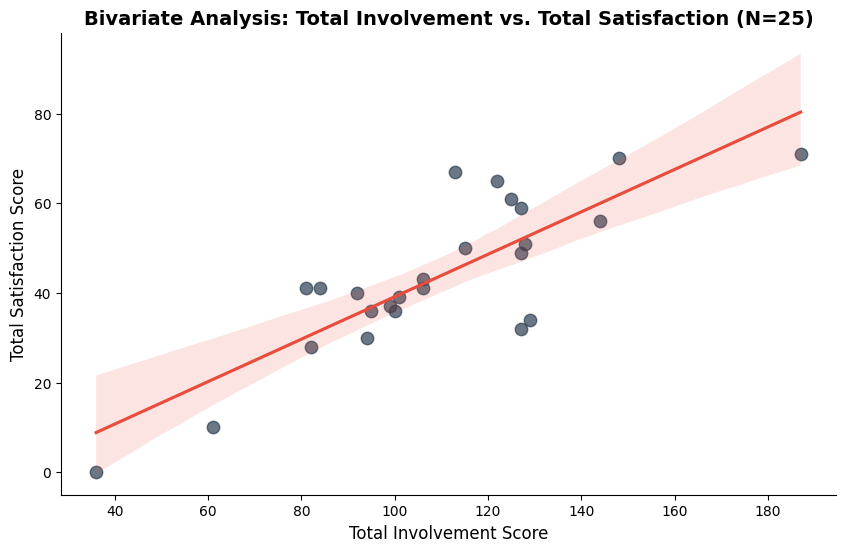

In [ ]:

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

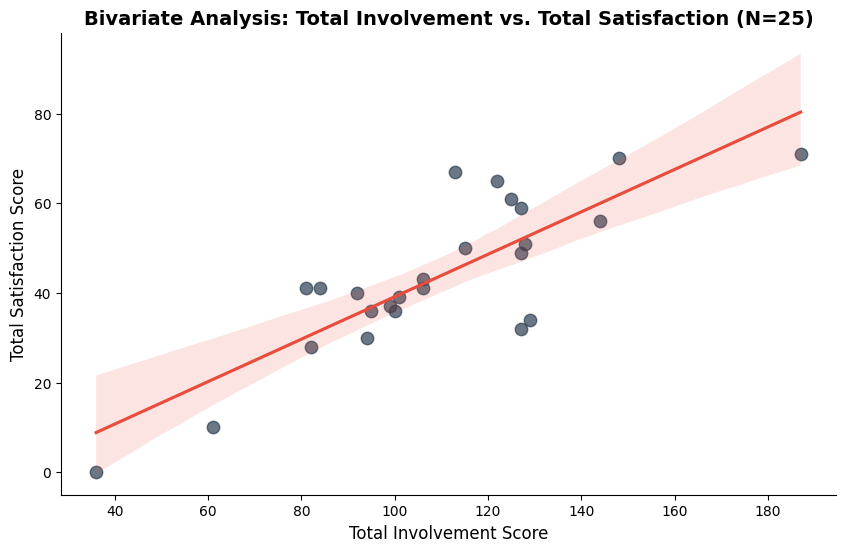

In [ ]:
df_clean['Total_Involvement'] = df_clean.filter(like='inv_').sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean.filter(like='sat_').sum(axis=1)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

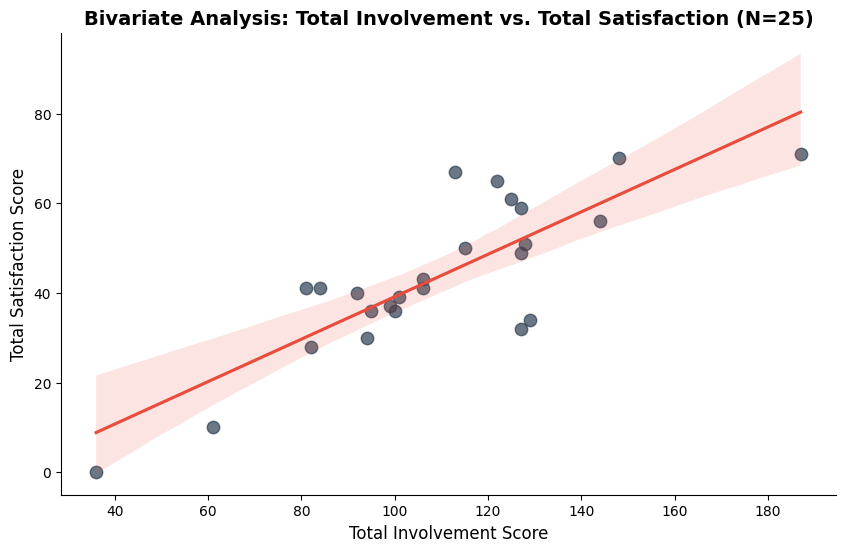

In [ ]:
df_clean['Total_Involvement'] = df_clean.filter(like='inv_').sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean.filter(like='sat_').sum(axis=1)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

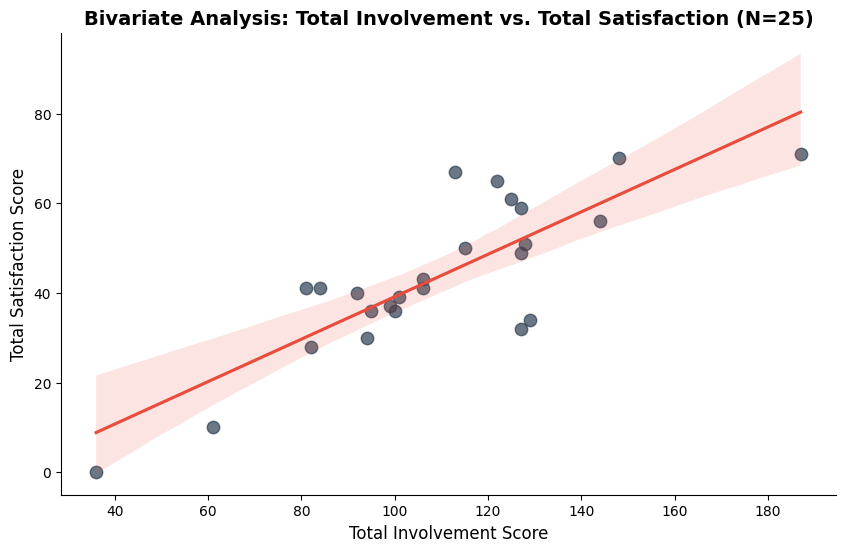

In [ ]:
df_clean['Total_Involvement'] = df_clean.filter(like='inv_').sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean.filter(like='sat_').sum(axis=1)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

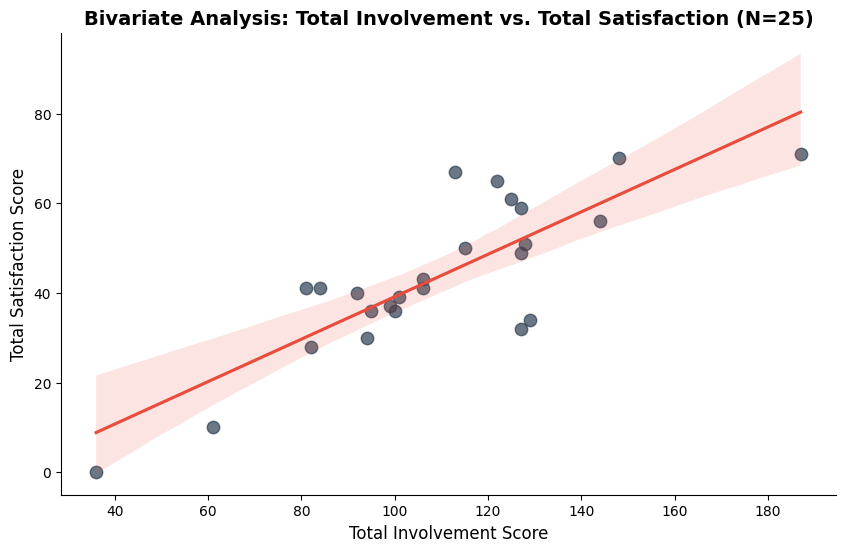

In [ ]:
df_clean['Total_Involvement'] = df_clean.filter(like='inv_').sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean.filter(like='sat_').sum(axis=1)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

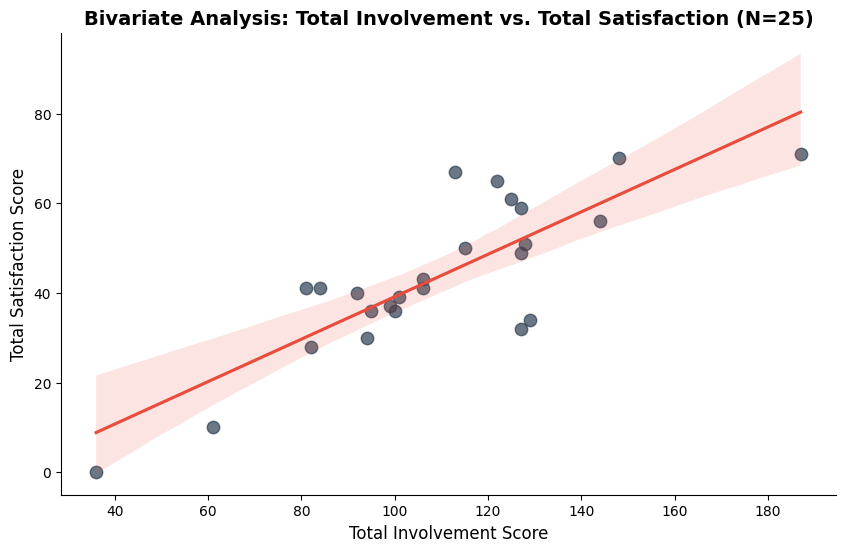

In [ ]:
df_clean['Total_Involvement'] = df_clean.filter(like='inv_').sum(axis=1)
df_clean['Total_Satisfaction'] = df_clean.filter(like='sat_').sum(axis=1)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='Total_Involvement',
    y='Total_Satisfaction',
    scatter_kws={'alpha': 0.7, 's': 80, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)

plt.title('Bivariate Analysis: Total Involvement vs. Total Satisfaction (N=25)', fontsize=14, fontweight='bold')
plt.xlabel('Total Involvement Score', fontsize=12)
plt.ylabel('Total Satisfaction Score', fontsize=12)

sns.despine()

plt.show()

Math to find total involvement score and total satisfaction score. Scatter plot graph to show the bivariate analysis.
*italicized text*

Code to run a T test on male versus female satisfaction.

T-statistic: -0.740
P-value: 0.467


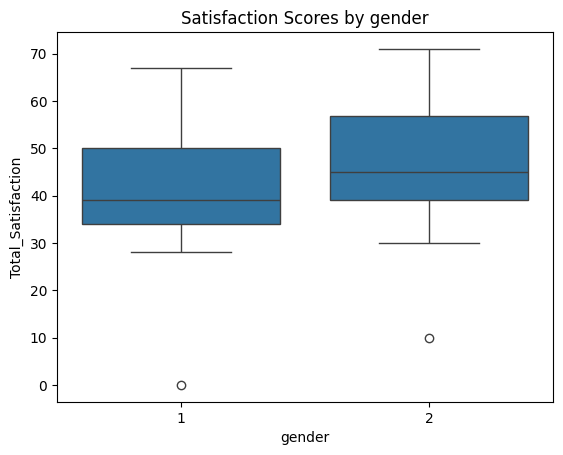

In [110]:
# Split the data into the two groups
males = df_clean[df_clean['gender'] == '1']['Total_Satisfaction']
females = df_clean[df_clean['gender'] == '2']['Total_Satisfaction']

# Independent t-test
t_stat, p_value = stats.ttest_ind(males, females)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Create a visual Box Plot
sns.boxplot(data=df_clean, x='gender', y='Total_Satisfaction')
plt.title('Satisfaction Scores by gender')
plt.show()